In [ ]:
# ENVIRONMENT CHECK -- run this first. Installs/upgrades this kernel's
# environment to the exact package versions this notebook was tested with.
# ===============================
import importlib.metadata 
import subprocess
import sys

REQUIRED = {
    "numpy": "2.3.2", "scipy": "1.17.1", "matplotlib": "3.10.6", "xarray": "2025.1.0",
    "shapely": "2.1.2", "pyproj": "3.7.2", "geopandas": "1.1.4", "openmdao": "3.40.0", "windIO": "2.1.1",
    "py_wake": "2.6.20", "optiwindnet": "0.3.0", "ortools": "9.15.6755",
    "h5py": "3.16.0", "netCDF4": "1.7.4", "openturns": "1.27.post1", "scikit-learn": "1.9.0",
}

def installed(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return None

mismatched = {p: v for p, v in REQUIRED.items() if installed(p) != v}

if mismatched:
    print(f"Installing {len(mismatched)} package(s) to the versions this notebook was tested with...")
    for pkg, version in mismatched.items():
        print(f"  {pkg}=={version} ...")
        result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'{pkg}=={version}'],
                                 capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-2000:])
            print(result.stderr[-2000:])
            raise RuntimeError(
                f"Could not install '{pkg}=={version}' automatically. Install it manually in this "
                f"kernel's environment (`{sys.executable} -m pip install {pkg}=={version}`) and re-run "
                f"this cell.")
    importlib.metadata.invalidate_caches()

print("Environment OK -- all versions match what this notebook was tested with.")


# 0. Setup

In [1]:
import os
import json
import urllib.parse
import urllib.request
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from PIL import Image, ImageDraw

DATA = "data"
os.makedirs(DATA, exist_ok=True)

# 1. Ingestion

## 1.1 Bathymetry — NOAA/NCEI ETOPO 2022 (15 arc-second)

- Dataset page / interactive query builder: https://coastwatch.pfeg.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.html
- ERDDAP griddap catalog (protocol docs, all datasets served this way): https://coastwatch.pfeg.noaa.gov/erddap/griddap/index.json

In [2]:
etopo_path = os.path.join(DATA, "etopo_east_coast_hires.nc")
etopo_url = ("https://coastwatch.pfeg.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.nc"
             "?z%5B(24.0):1:(47.5)%5D%5B(-82.5):1:(-66.0)%5D")
if not os.path.exists(etopo_path):
    urllib.request.urlretrieve(etopo_url, etopo_path)

## 1.2 Offshore wind lease areas — BOEM Renewable Energy GIS

- Layer discovered via ArcGIS Online search API: https://www.arcgis.com/sharing/rest/search?q=BOEM%20Wind%20Lease%20Outlines&f=json
- FeatureServer layer queried (REST query docs at bottom of page): https://services7.arcgis.com/G5Ma95RzqJRPKsWL/arcgis/rest/services/Wind_Lease_Boundaries__BOEM_/FeatureServer/8
- BOEM's own GIS data portal (confirms this is the official layer): https://www.boem.gov/renewable-energy/mapping-and-data/renewable-energy-gis-data

In [3]:
leases_path = os.path.join(DATA, "boem_leases.geojson")
leases_url = ("https://services7.arcgis.com/G5Ma95RzqJRPKsWL/arcgis/rest/services/"
              "Wind_Lease_Boundaries__BOEM_/FeatureServer/8/query"
              "?where=1%3D1&outFields=*&outSR=4326&f=geojson")
if not os.path.exists(leases_path):
    urllib.request.urlretrieve(leases_url, leases_path)

## 1.3 US state boundaries — land basemap

- Repo: https://github.com/PublicaMundi/MappingAPI
- Raw file fetched directly (public raw GitHub content, no key): https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json

In [4]:
states_path = os.path.join(DATA, "us_states.json")
states_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
if not os.path.exists(states_path):
    urllib.request.urlretrieve(states_url, states_path)

## 1.4 Lakes — Great Lakes / inland water mask

- Natural Earth, public domain vector data: https://www.naturalearthdata.com/
- Mirror repo used for direct raw access: https://github.com/nvkelso/natural-earth-vector
- Raw file fetched: https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_lakes.geojson

In [5]:
lakes_path = os.path.join(DATA, "ne_lakes.geojson")
lakes_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_lakes.geojson"
if not os.path.exists(lakes_path):
    urllib.request.urlretrieve(lakes_url, lakes_path)

## 1.5 Global country boundaries — world basemap

- Natural Earth 110m admin-0 countries, same source as §1.4: https://www.naturalearthdata.com/
- Raw file fetched: https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson

In [6]:
countries_path = os.path.join(DATA, "ne_countries_110m.geojson")
countries_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
if not os.path.exists(countries_path):
    urllib.request.urlretrieve(countries_url, countries_path)

## 1.6 Global Wind Power Tracker — Global Energy Monitor

- Project page — download gated behind a free name/email form (`<gem-download-form>` widget), not scriptable: https://globalenergymonitor.org/projects/global-wind-power-tracker/

In [7]:
gwpt_path = os.path.join(DATA, "global_wind_power_tracker.xlsx")
assert os.path.exists(gwpt_path), "download manually from the GEM page above, place in data/"

## 1.7 OCS block grid — BOEM Aliquot 16ths

- FeatureServer layer: https://services7.arcgis.com/G5Ma95RzqJRPKsWL/arcgis/rest/services/OCS_Aliquot_16ths_Polygons___3rd_Division/FeatureServer/6
- BOEM's own GIS data portal: https://www.boem.gov/renewable-energy/mapping-and-data/renewable-energy-gis-data

In [8]:
def query_all_features(url, params):
    features, offset = [], 0
    while True:
        q = dict(params, resultOffset=offset, resultRecordCount=2000)
        with urllib.request.urlopen(f"{url}?{urllib.parse.urlencode(q)}", timeout=60) as r:
            page = json.load(r)
        batch = page.get("features", [])
        features.extend(batch)
        if len(batch) < 2000:
            break
        offset += 2000
    return {"type": "FeatureCollection", "features": features}

ARCGIS_ROOT = "https://services7.arcgis.com/G5Ma95RzqJRPKsWL/arcgis/rest/services"
BBOX = "-71.9,40.3,-69.7,41.5"
BASE_PARAMS = {"geometry": BBOX, "geometryType": "esriGeometryEnvelope", "inSR": "4326",
               "spatialRel": "esriSpatialRelIntersects", "outFields": "*", "outSR": "4326", "f": "geojson"}

In [9]:
blocks_path = os.path.join(DATA, "ocs_aliquot16_ri_ma.geojson")
if not os.path.exists(blocks_path):
    data = query_all_features(f"{ARCGIS_ROOT}/OCS_Aliquot_16ths_Polygons___3rd_Division/FeatureServer/6/query", BASE_PARAMS)
    json.dump(data, open(blocks_path, "w"))

## 1.8 Federal/state boundary — BOEM Offshore Boundary Lines

- FeatureServer layer: https://services7.arcgis.com/G5Ma95RzqJRPKsWL/arcgis/rest/services/OCS_BOEM_Offshore_Boundary_Lines/FeatureServer/8

In [10]:
boundary_path = os.path.join(DATA, "fed_state_boundary_ri_ma.geojson")
if not os.path.exists(boundary_path):
    data = query_all_features(f"{ARCGIS_ROOT}/OCS_BOEM_Offshore_Boundary_Lines/FeatureServer/8/query", BASE_PARAMS)
    json.dump(data, open(boundary_path, "w"))

# 2. Fixed-bottom vs Floating Screening

## 2.1 Load & Classify

In [11]:
ds = xr.open_dataset(os.path.join(DATA, "etopo_east_coast_hires.nc"))
z = ds["z"].values
lat = ds["latitude"].values
lon = ds["longitude"].values
depth = -z

classes = np.zeros(z.shape, dtype="uint8")
classes[(z < 0) & (depth > 0) & (depth < 60)] = 1
classes[(z < 0) & (depth >= 60)] = 2

leases = gpd.read_file(os.path.join(DATA, "boem_leases.geojson"))
leases = leases[leases["LEASE_TYPE"] != "Easement"]
states = gpd.read_file(os.path.join(DATA, "us_states.json"))
states_region = states.cx[-87:-63, 22:49]
lakes = gpd.read_file(os.path.join(DATA, "ne_lakes.geojson"))
lakes_region = lakes.cx[-83:-65, 23:48]

In [12]:
ncols, nrows = len(lon), len(lat)
dlon = (lon[-1] - lon[0]) / (ncols - 1)
dlat = (lat[-1] - lat[0]) / (nrows - 1)

def to_px(x, y):
    return ((x - lon[0]) / dlon, (y - lat[0]) / dlat)

# rasterize the lake polygons onto the grid to null out bathymetry under them
lake_mask_img = Image.new("1", (ncols, nrows), 0)
draw = ImageDraw.Draw(lake_mask_img)
for geom in lakes_region.geometry:
    if geom is None:
        continue
    polys = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    for poly in polys:
        xs, ys = poly.exterior.coords.xy
        draw.polygon([to_px(x, y) for x, y in zip(xs, ys)], fill=1)
        for interior in poly.interiors:
            xs, ys = interior.coords.xy
            draw.polygon([to_px(x, y) for x, y in zip(xs, ys)], fill=0)
lake_mask = np.array(lake_mask_img, dtype=bool)
classes[lake_mask] = 0

depth_contour = depth.copy()
depth_contour[(z >= 0) | lake_mask] = np.nan

## 2.2 Plot

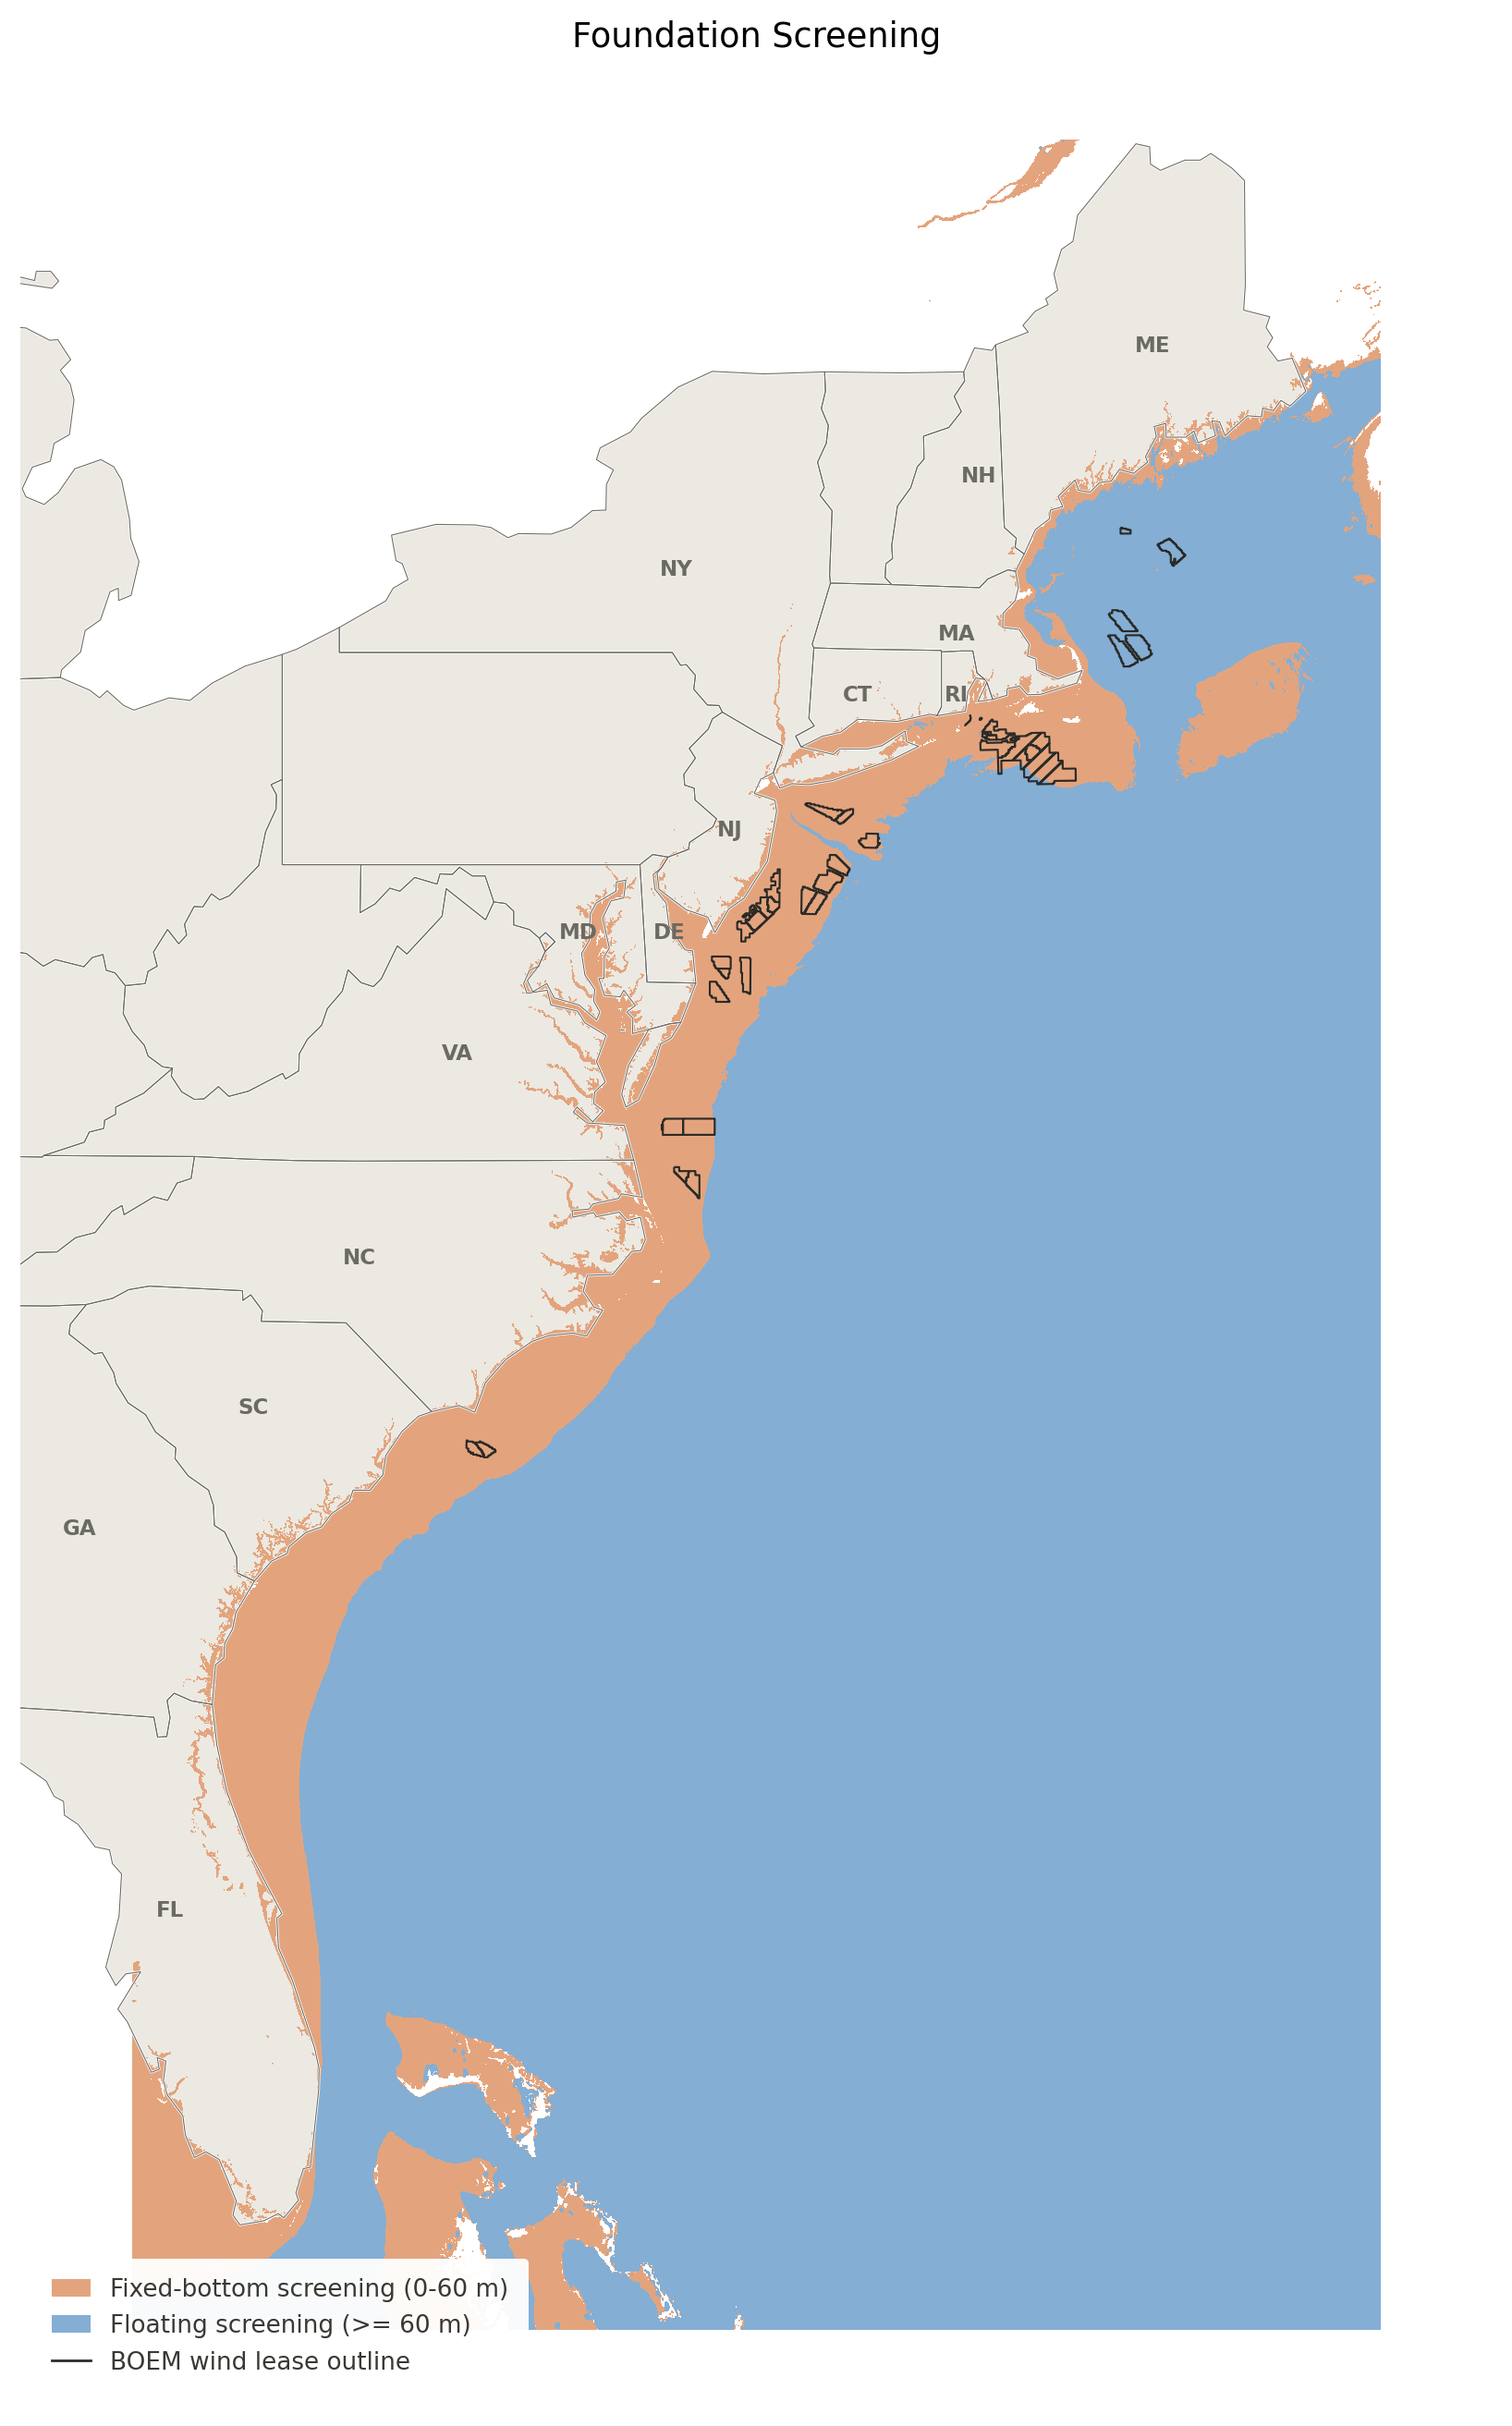

In [13]:
COLOR_LAND = "#ece9e2"
COLOR_FIXED = "#e3a47d"
COLOR_FLOAT = "#84aed4"
COLOR_LEASE = "#2b2a27"
COLOR_MUTED = "#6b6a63"
COLOR_INK = "#3a3833"

LON_MIN, LON_MAX = lon.min(), lon.max()
LAT_MIN, LAT_MAX = lat.min(), lat.max()
mean_lat = np.deg2rad((LAT_MIN + LAT_MAX) / 2)
lon_pad = (LON_MAX - LON_MIN) * 0.09
lat_pad = (LAT_MAX - LAT_MIN) * 0.035

fig, ax = plt.subplots(figsize=(11.2, 12), dpi=220)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

states_region.plot(ax=ax, facecolor=COLOR_LAND, edgecolor="none", zorder=1)

depth_fill = np.nan_to_num(depth_contour, nan=-1.0)
depth_fill = np.ma.masked_array(depth_fill, mask=np.isnan(depth_contour))
ax.contourf(lon, lat, depth_fill, levels=[0, 60, 1.0e5], colors=[COLOR_FIXED, COLOR_FLOAT], zorder=2)

states_region.boundary.plot(ax=ax, color="white", linewidth=0.9, zorder=3)
states_region.boundary.plot(ax=ax, color=COLOR_MUTED, linewidth=0.35, zorder=4)
leases.boundary.plot(ax=ax, color=COLOR_LEASE, linewidth=0.7, zorder=5)

ax.set_xlim(LON_MIN - lon_pad, LON_MAX + lon_pad)
ax.set_ylim(LAT_MIN - lat_pad, LAT_MAX + lat_pad)
ax.set_aspect(1 / np.cos(mean_lat))
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

label_pts = {
    "ME": (-69.0, 45.3), "NH": (-71.3, 43.9), "MA": (-71.6, 42.2), "RI": (-71.6, 41.55),
    "CT": (-72.9, 41.55), "NY": (-75.3, 42.9), "NJ": (-74.6, 40.1), "DE": (-75.4, 39.0),
    "MD": (-76.6, 39.0), "VA": (-78.2, 37.7), "NC": (-79.5, 35.5), "SC": (-80.9, 33.9),
    "GA": (-83.2, 32.6), "FL": (-82.0, 28.5),
}
for name, (x, y) in label_pts.items():
    ax.text(x, y, name, fontsize=7.5, color=COLOR_MUTED, ha="center", va="center", fontweight="bold", zorder=6)

legend_elems = [
    mpatches.Patch(facecolor=COLOR_FIXED, edgecolor="none", label="Fixed-bottom screening (0-60 m)"),
    mpatches.Patch(facecolor=COLOR_FLOAT, edgecolor="none", label="Floating screening (>= 60 m)"),
    Line2D([0], [0], color=COLOR_LEASE, linewidth=0.9, label="BOEM wind lease outline"),
]
leg = ax.legend(handles=legend_elems, loc="lower left", frameon=True, fontsize=8.6,
                 framealpha=0.95, edgecolor="none", facecolor="white", borderpad=0.8, handlelength=1.6)
for t in leg.get_texts():
    t.set_color(COLOR_INK)

plt.title("Foundation Screening")
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
fig.savefig("atlantic_wind_foundation_screening.png", dpi=220, facecolor="white")
plt.show()

# 3. Global Offshore Wind Pipeline

## 3.1 Load & Filter

In [14]:
df = pd.read_excel(os.path.join(DATA, "global_wind_power_tracker.xlsx"), sheet_name="Data")

offshore_types = ["Offshore hard mount", "Offshore mount unknown", "Offshore floating"]
status_map = {
    "announced": "Announced",
    "pre-construction": "Pre-construction",
    "construction": "Construction",
    "operating": "Operating",
    "retired": "Decommissioned",
}
df = df[df["Installation Type"].isin(offshore_types)]
df = df[df["Status"].isin(status_map.keys())].copy()
df["Stage"] = df["Status"].map(status_map)

countries = gpd.read_file(os.path.join(DATA, "ne_countries_110m.geojson"))
countries = countries[countries["NAME"] != "Antarctica"]
df.groupby("Stage")["Capacity (MW)"].agg(["count", "sum"]).round(1)

,count,sum
Stage,,
Announced,419,536516.2
Construction,93,47101.0
Decommissioned,3,38.0
Operating,367,91377.7
Pre-construction,610,501269.0


## 3.2 Plot

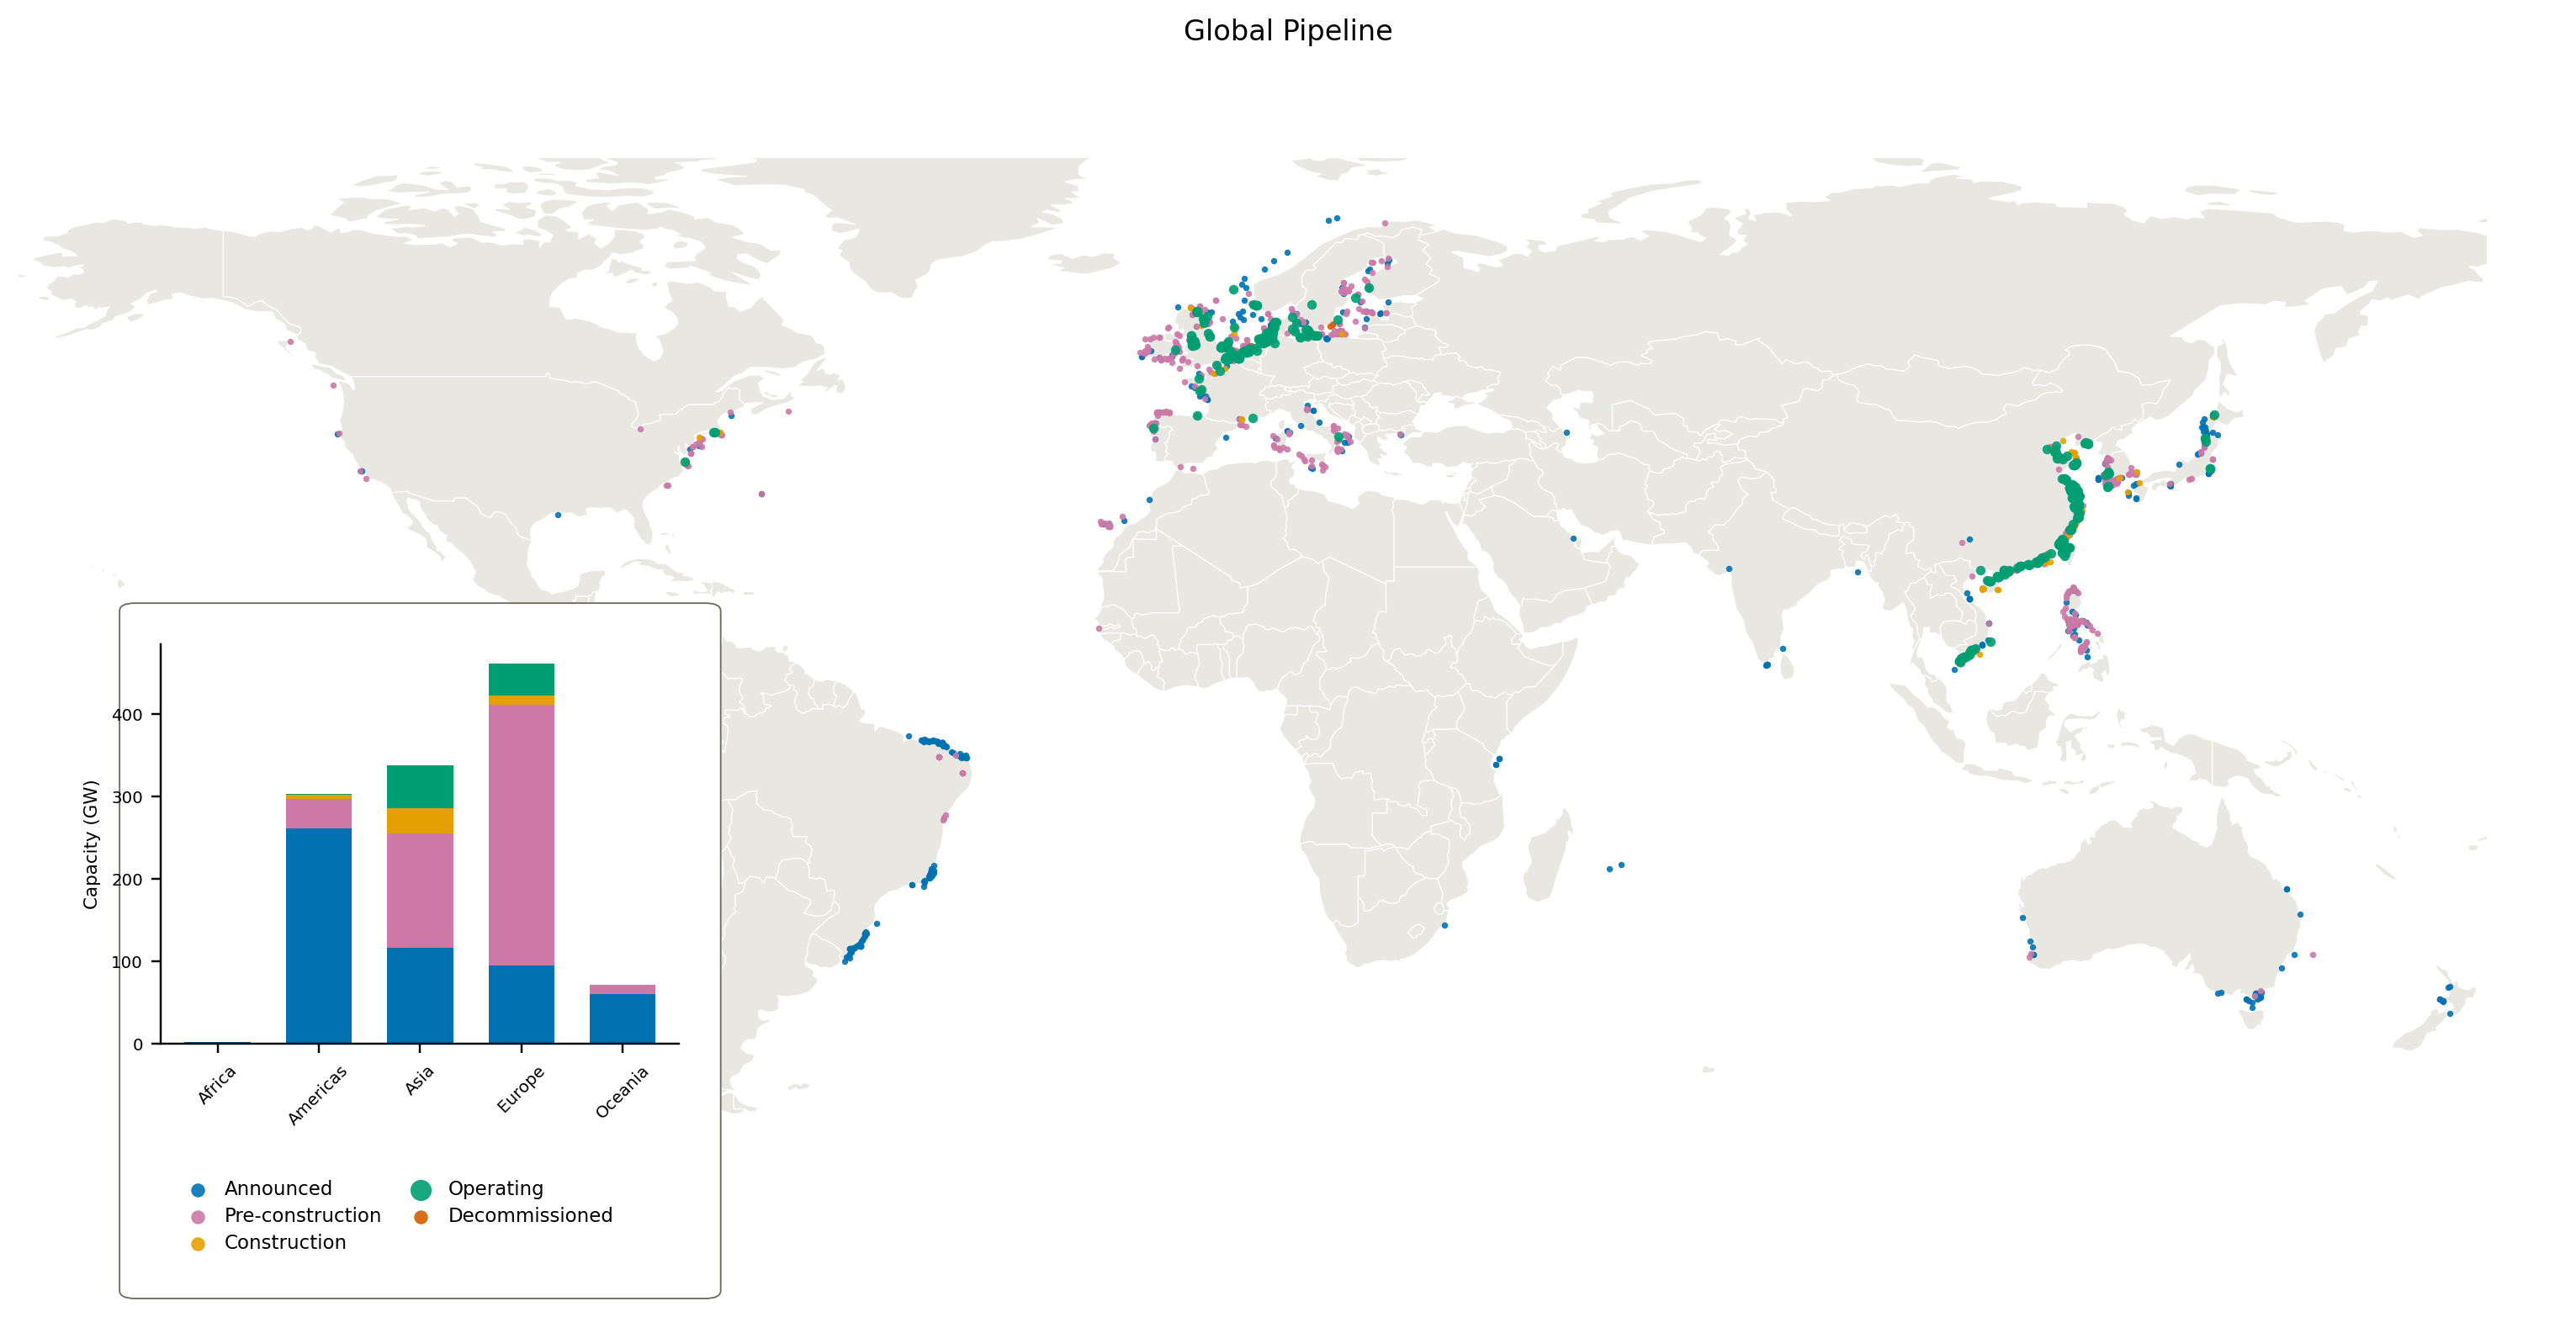

In [15]:
COLORS = {
    "Announced": "#0072B2",
    "Pre-construction": "#CC79A7",
    "Construction": "#E69F00",
    "Operating": "#009E73",
    "Decommissioned": "#D55E00",
}
STAGE_ORDER = ["Announced", "Pre-construction", "Construction", "Operating", "Decommissioned"]
DRAW_ORDER = ["Announced", "Pre-construction", "Construction", "Decommissioned", "Operating"]

fig, ax = plt.subplots(figsize=(14, 7.2), dpi=220)
countries.plot(ax=ax, facecolor="#e9e7e1", edgecolor="white", linewidth=0.4, zorder=1)

for i, stage in enumerate(DRAW_ORDER):
    sub = df[df["Stage"] == stage]
    size = 14 if stage == "Operating" else 6
    ax.scatter(sub["Longitude"], sub["Latitude"], s=size, color=COLORS[stage],
               label=stage, alpha=0.9, linewidths=0, zorder=2 + i)

handles_by_label = dict(zip(*ax.get_legend_handles_labels()[::-1]))

ax.set_xlim(-170, 190)
ax.set_ylim(-58, 80)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [handles_by_label[s] for s in STAGE_ORDER]
labels = STAGE_ORDER

inset = fig.add_axes([0.065, 0.20, 0.20, 0.30])
region_gw = (df.groupby(["Region", "Stage"])["Capacity (MW)"].sum().unstack(fill_value=0) / 1000)
region_gw = region_gw.reindex(columns=STAGE_ORDER, fill_value=0)
region_gw = region_gw.reindex(["Africa", "Americas", "Asia", "Europe", "Oceania"])
bottom = None
for stage in STAGE_ORDER:
    vals = region_gw[stage]
    inset.bar(region_gw.index, vals, bottom=bottom, color=COLORS[stage], width=0.65)
    bottom = vals if bottom is None else bottom + vals
inset.set_ylabel("Capacity (GW)", fontsize=7)
inset.tick_params(axis="x", labelrotation=45, labelsize=6.5)
inset.tick_params(axis="y", labelsize=6.5)
inset.set_facecolor("white")
for spine in ["top", "right"]:
    inset.spines[spine].set_visible(False)

leg = fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.065, 0.03),
                  ncol=2, fontsize=7.5, frameon=False, markerscale=2.2,
                  columnspacing=1.0, handletextpad=0.4, labelspacing=0.4)

box = mpatches.FancyBboxPatch((0.055, 0.015), 0.22, 0.51, transform=fig.transFigure,
                               boxstyle="round,pad=0.006", linewidth=0.6,
                               edgecolor="#6b6a63", facecolor="white", zorder=0)
fig.patches.append(box)
inset.set_zorder(1)
leg.set_zorder(1)

fig.suptitle("Global Pipeline", fontsize=11, y=0.97)
plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
fig.savefig("global_offshore_wind_map.png", dpi=220, facecolor="white")
plt.show()

# 4. RI/MA Lease Blocks

## 4.1 Load

In [16]:
LON_MIN, LON_MAX = -71.75, -69.75
LAT_MIN, LAT_MAX = 40.45, 41.45

ds_rm = xr.open_dataset(os.path.join(DATA, "etopo_east_coast_hires.nc"))
sub = ds_rm.sel(latitude=slice(LAT_MIN, LAT_MAX), longitude=slice(LON_MIN, LON_MAX))
z_rm = sub["z"].values
lat_rm = sub["latitude"].values
lon_rm = sub["longitude"].values

blocks = gpd.read_file(os.path.join(DATA, "ocs_aliquot16_ri_ma.geojson"))
leases_rm = gpd.read_file(os.path.join(DATA, "boem_leases.geojson"))
leases_rm = leases_rm[leases_rm["LEASE_TYPE"] != "Easement"]
leases_rm = leases_rm.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX]
boundary = gpd.read_file(os.path.join(DATA, "fed_state_boundary_ri_ma.geojson"))
boundary = boundary[boundary["BDRY_TYPE_CODE"] == "S"]

## 4.2 Plot

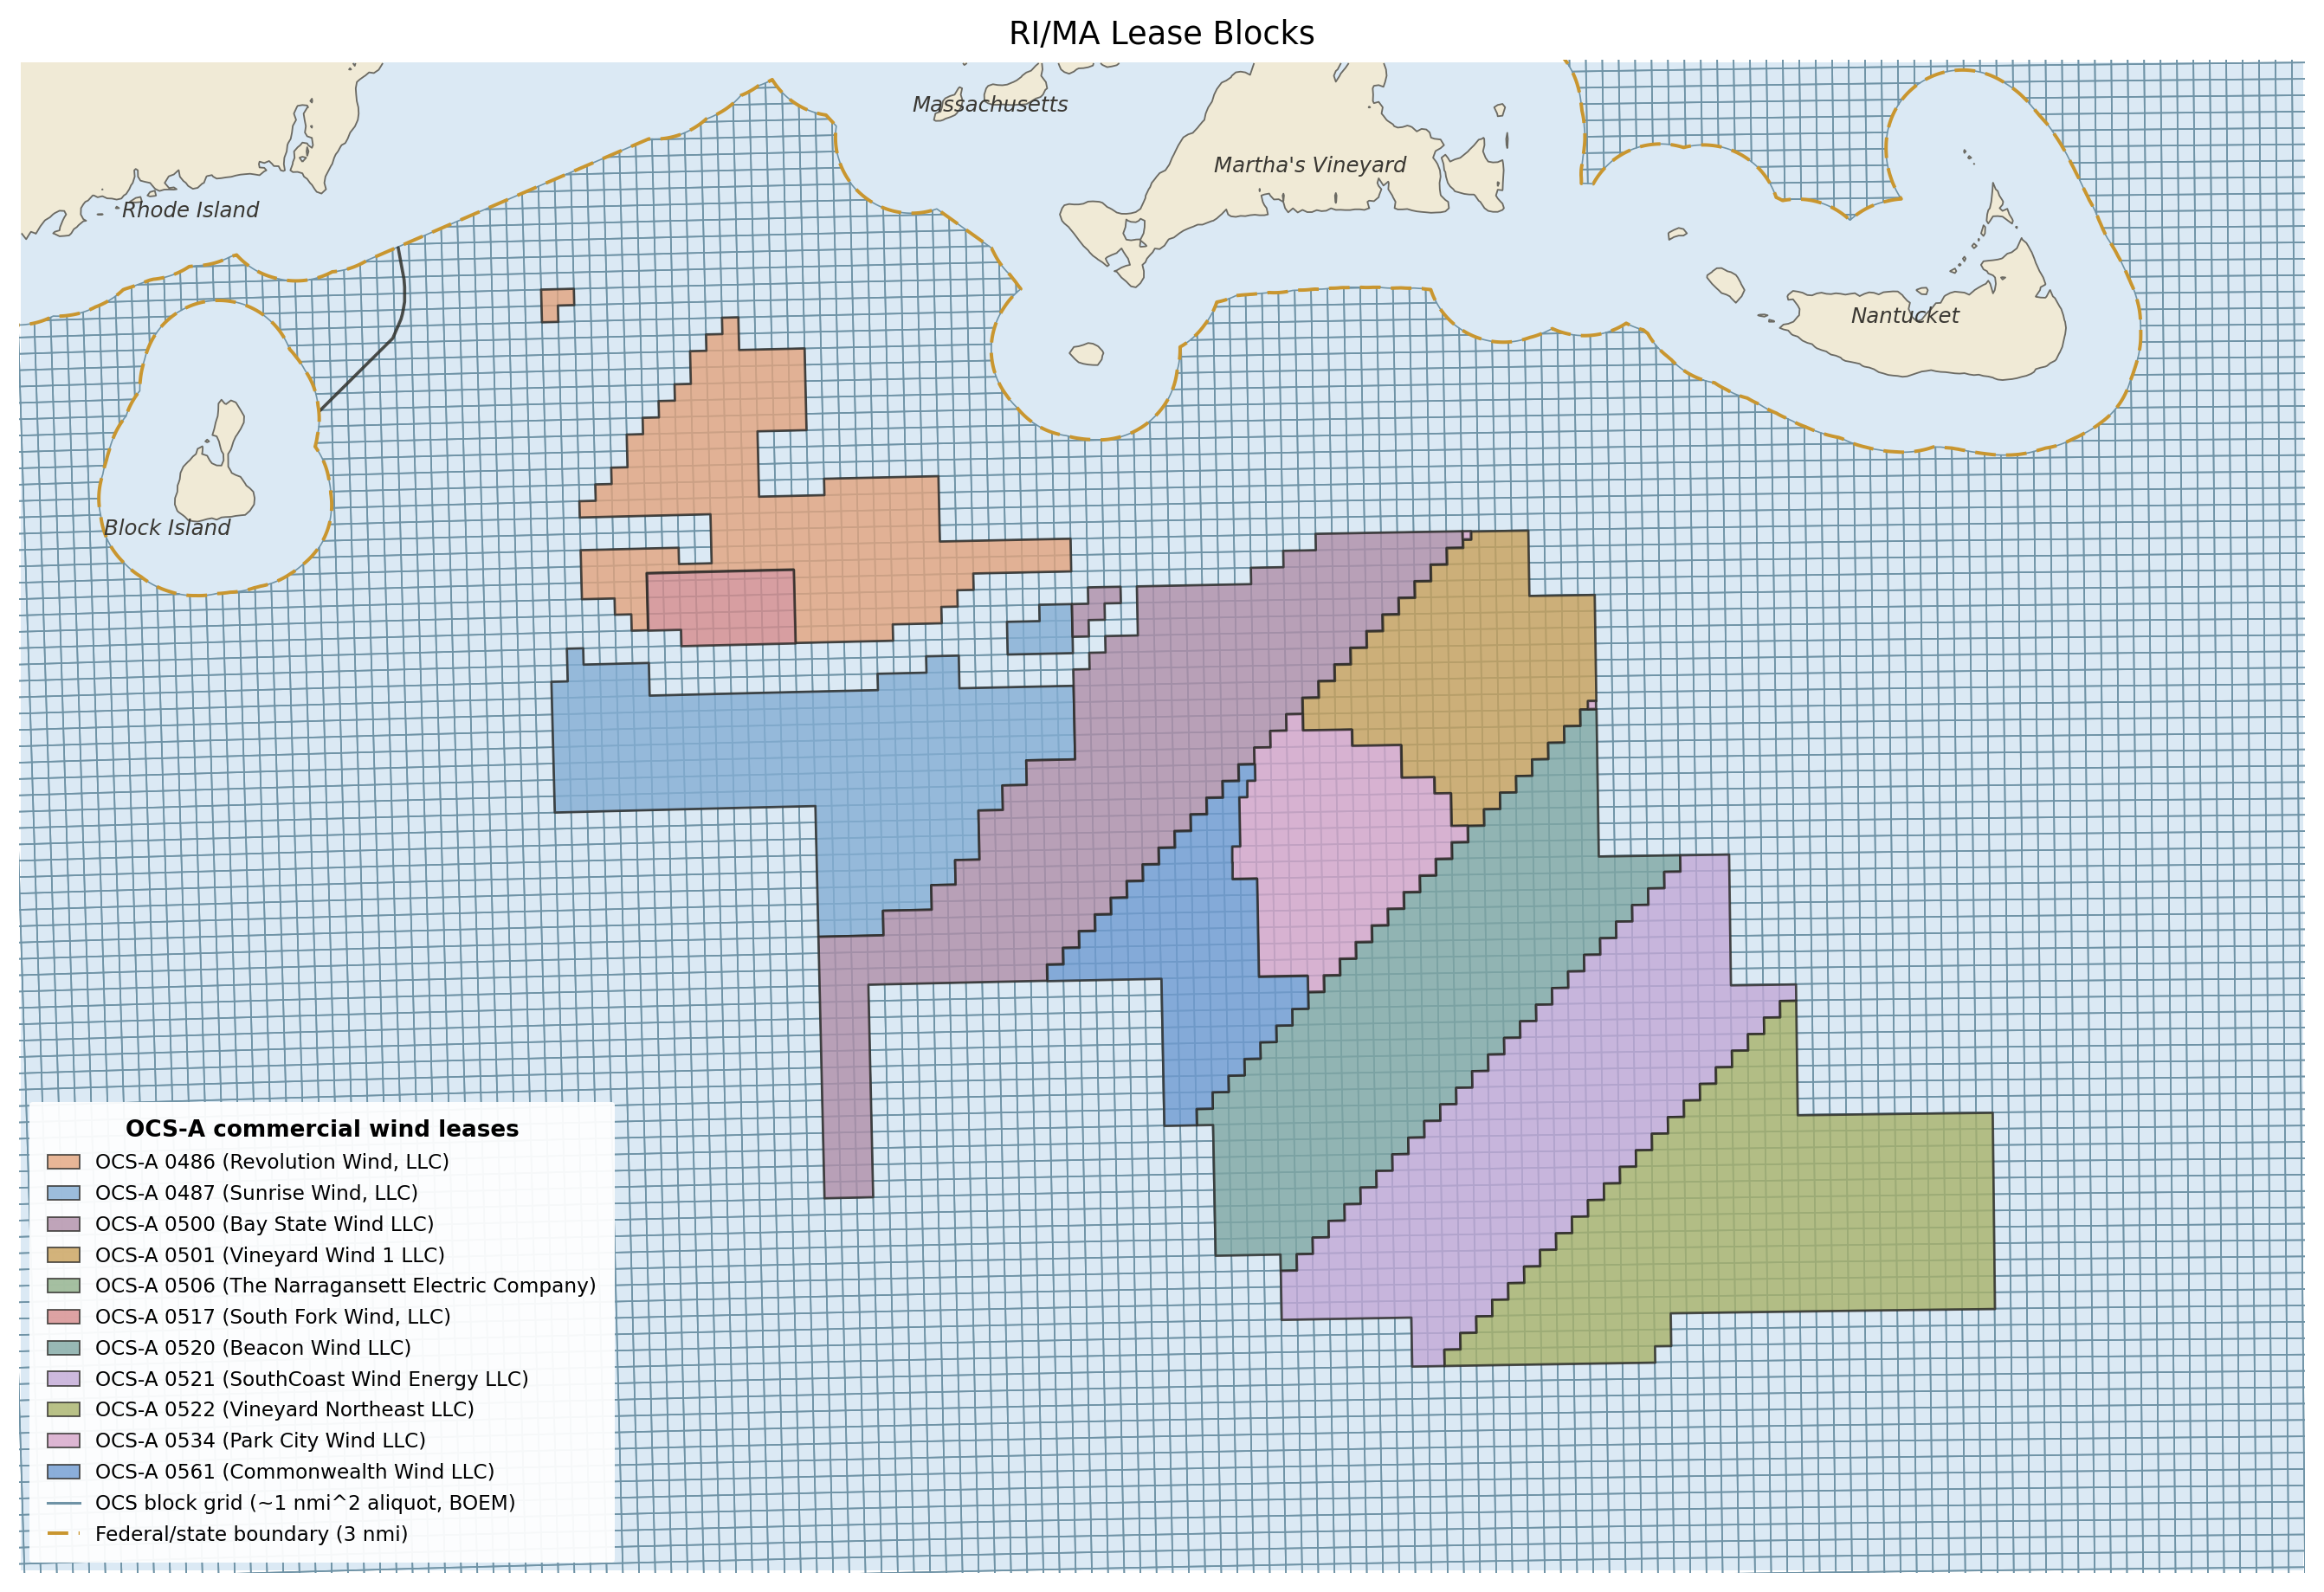

In [17]:
LEASE_COLORS = ["#e3a47d", "#84aed4", "#b08ea8", "#c9a15a", "#8fb08a",
                 "#d68c8c", "#7fa7a3", "#c2a8d6", "#a8b26a", "#d6a5c9",
                 "#6f9bd1", "#e0b96e"]
lease_labels = {}
color_by_num = {}
for i, (_, row) in enumerate(leases_rm.sort_values("LEASE_NUMBER").iterrows()):
    color_by_num[row["LEASE_NUMBER"]] = LEASE_COLORS[i % len(LEASE_COLORS)]
    lease_labels[row["LEASE_NUMBER"]] = f"{row['LEASE_NUMBER']} ({row['COMPANY'].strip()})"

mean_lat_rad = np.deg2rad((LAT_MIN + LAT_MAX) / 2)
aspect = (LAT_MAX - LAT_MIN) / ((LON_MAX - LON_MIN) * np.cos(mean_lat_rad))
fig_width = 12.0
fig, ax = plt.subplots(figsize=(fig_width, fig_width * aspect), dpi=220)

ax.contourf(lon_rm, lat_rm, z_rm, levels=[-1e5, 0, 1e5], colors=["#dbe9f4", "#f0ead6"], zorder=1)
ax.contour(lon_rm, lat_rm, z_rm, levels=[0], colors="#6b6a63", linewidths=0.6, zorder=2)

blocks.boundary.plot(ax=ax, color="#6f93a6", linewidth=0.55, zorder=3)

for _, row in leases_rm.iterrows():
    gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor=color_by_num[row["LEASE_NUMBER"]],
                                        edgecolor="#2b2a27", linewidth=0.9, alpha=0.8, zorder=4)

boundary.plot(ax=ax, color="#c9962f", linewidth=1.3, linestyle=(0, (6, 3)), zorder=5)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect(1 / np.cos(mean_lat_rad))
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

labels = {
    "Rhode Island": (-71.6, 41.35),
    "Massachusetts": (-70.9, 41.42),
    "Block Island": (-71.62, 41.14),
    "Martha's Vineyard": (-70.62, 41.38),
    "Nantucket": (-70.1, 41.28),
}
for name, (x, y) in labels.items():
    ax.text(x, y, name, fontsize=8, color="#3a3833", ha="center", va="center",
            style="italic", zorder=6)

lease_handles = [mpatches.Patch(facecolor=color_by_num[n], edgecolor="#2b2a27", linewidth=0.6,
                                 alpha=0.8, label=lease_labels[n])
                  for n in sorted(color_by_num)]
other_handles = [
    Line2D([0], [0], color="#6f93a6", linewidth=1.0, label="OCS block grid (~1 nmi^2 aliquot, BOEM)"),
    Line2D([0], [0], color="#c9962f", linewidth=1.3, linestyle=(0, (6, 3)), label="Federal/state boundary (3 nmi)"),
]
leg = ax.legend(handles=lease_handles + other_handles, loc="lower left", frameon=True,
                 fontsize=7.6, framealpha=0.94, edgecolor="none", facecolor="white",
                 borderpad=0.9, handlelength=1.6, title="OCS-A commercial wind leases",
                 title_fontsize=8.6, labelspacing=0.55)
leg.get_title().set_fontweight("bold")
leg.set_zorder(10)

plt.title("RI/MA Lease Blocks")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig("ri_ma_lease_blocks_map.png", dpi=220, facecolor="white", bbox_inches="tight", pad_inches=0.01)
plt.show()